# Flight Demand & Price Forecasting — Southern Africa

**Business question.** Forecast flight prices and daily route volume so airlines can tune dynamic pricing and operations can plan crew/aircraft.

**Pipeline:** business question → data & EDA → SARIMA volume forecast + GBM price predictor → validation → deployment.

**Data:** [mazano/southern-africa-flight-prices](https://www.kaggle.com/datasets/mazano/southern-africa-flight-prices) — 15,393 flights with route, airline, timestamps, price.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load + clean

In [2]:
df = pd.read_csv('data/flights.csv')
# departure/arrival are unix-like timestamps — convert
df['departure'] = pd.to_datetime(df['departure'], unit='s', errors='coerce')
df['arrival'] = pd.to_datetime(df['arrival'], unit='s', errors='coerce')
df['route'] = df['from'] + '-' + df['to']
df['date'] = df['departure'].dt.floor('D')
df['dow'] = df['departure'].dt.dayofweek
df['hour'] = df['departure'].dt.hour
print(f'rows: {len(df):,}, date range: {df.date.min().date()} → {df.date.max().date()}')
df.head(3)

rows: 15,393, date range: 2025-03-14 → 2025-04-13


,id,from,to,airline,departure,arrival,price,route,date,dow,hour
0,1,CPT,DUR,FlySafair,2025-03-15 15:45:00,2025-03-15 17:50:00,762,CPT-DUR,2025-03-15,5,15
1,2,CPT,DUR,LIFT Airline,2025-03-15 05:10:00,2025-03-15 07:15:00,865,CPT-DUR,2025-03-15,5,5
2,3,CPT,DUR,LIFT Airline,2025-03-15 11:30:00,2025-03-15 13:35:00,865,CPT-DUR,2025-03-15,5,11


## 3. EDA

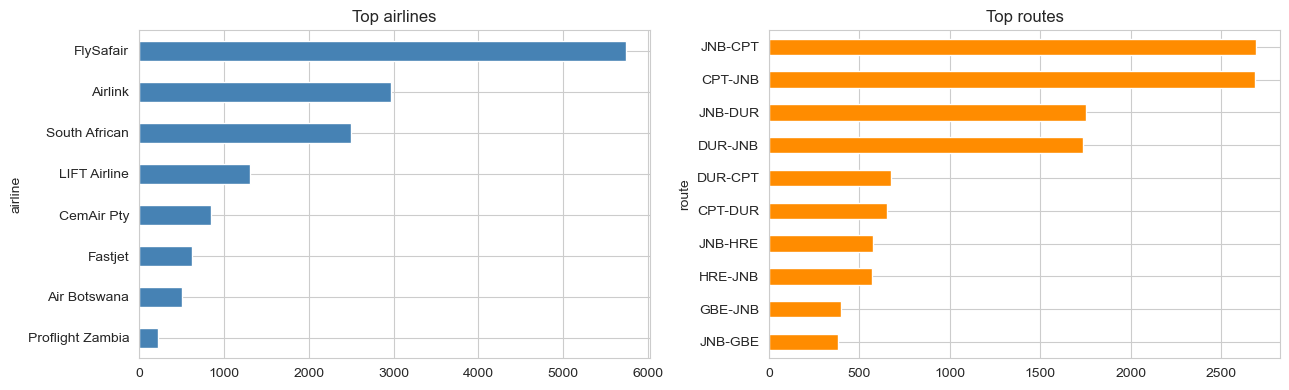

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['airline'].value_counts().head(8).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top airlines'); axes[0].invert_yaxis()
df['route'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top routes'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

Top route: JNB-CPT, days observed: 30


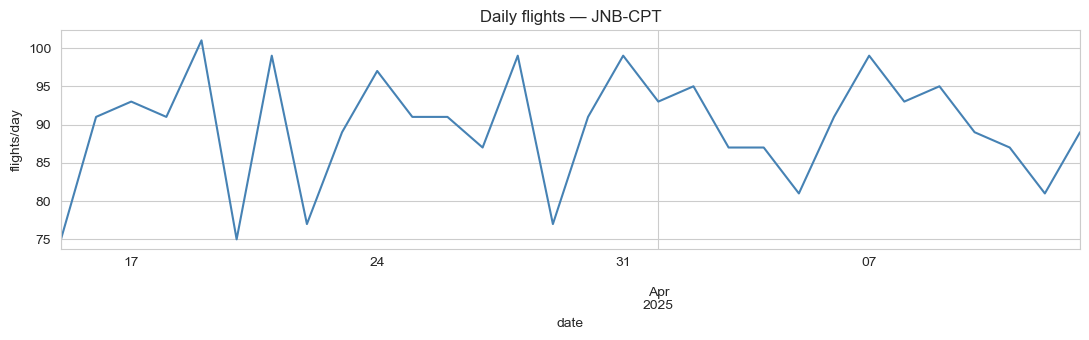

In [4]:
# Daily volume on top route
top_route = df['route'].value_counts().index[0]
vol = df[df['route'] == top_route].groupby('date').size().sort_index()
vol = vol.asfreq('D').fillna(0)
print(f'Top route: {top_route}, days observed: {len(vol)}')
fig, ax = plt.subplots(figsize=(11, 3.5))
vol.plot(ax=ax, color='steelblue')
ax.set_title(f'Daily flights — {top_route}'); ax.set_ylabel('flights/day')
plt.tight_layout(); plt.show()

## 4. Modeling

In [5]:
# 4a. SARIMA on daily volume of top route
n_test = min(7, max(2, len(vol)//5))
train_v, test_v = vol.iloc[:-n_test], vol.iloc[-n_test:]
sarima = SARIMAX(train_v, order=(1,0,1), seasonal_order=(1,0,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = sarima.get_forecast(n_test)
mean_fc = fc.predicted_mean; ci = fc.conf_int()
print(f'SARIMA AIC = {sarima.aic:.0f}, train days = {len(train_v)}')

SARIMA AIC = 98, train days = 24


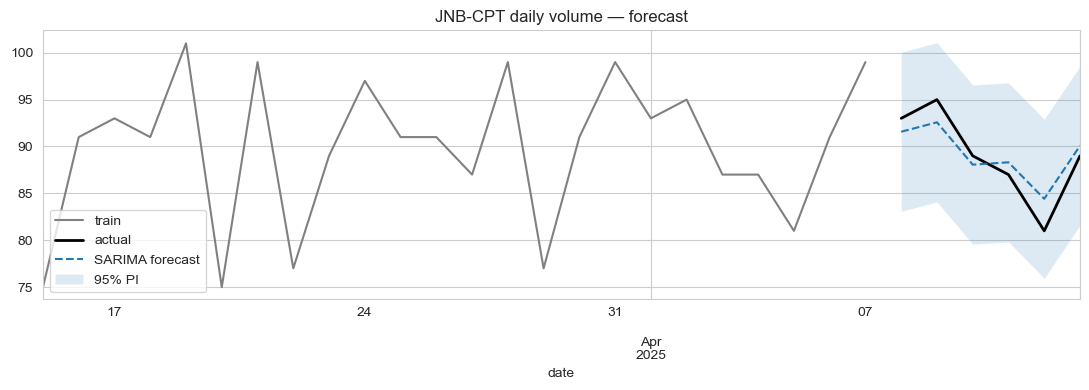

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
train_v.plot(ax=ax, color='gray', label='train')
test_v.plot(ax=ax, color='black', linewidth=2, label='actual')
mean_fc.plot(ax=ax, label='SARIMA forecast', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.15, label='95% PI')
ax.set_title(f'{top_route} daily volume — forecast'); ax.legend(); plt.tight_layout(); plt.show()

In [7]:
# 4b. GBM price predictor — features: route, airline, dow, hour, days-to-departure
ref_now = df['departure'].min()
df['days_ahead'] = (df['departure'] - ref_now).dt.days
Xy = df[['route','airline','dow','hour','days_ahead','price']].dropna().copy()
X = pd.concat([Xy[['dow','hour','days_ahead']],
               pd.get_dummies(Xy[['route','airline']], drop_first=True).astype(float)], axis=1)
y = Xy['price'].astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
yhat = gbm.predict(Xte)
print(f'price n_features: {X.shape[1]}, train rows: {len(Xtr):,}')

price n_features: 63, train rows: 12,314


## 5. Validation

In [8]:
# Volume forecast metrics
vol_mape = mean_absolute_percentage_error(test_v.values, mean_fc.values) if (test_v.values > 0).all() else np.nan
vol_rmse = float(np.sqrt(mean_squared_error(test_v, mean_fc)))
# Price prediction metrics
price_mae = mean_absolute_error(yte, yhat); price_rmse = float(np.sqrt(mean_squared_error(yte, yhat)))
price_mape = mean_absolute_percentage_error(yte, yhat)
scores = pd.DataFrame([
    {'task': f'Volume forecast ({top_route})', 'metric_1': f'MAPE={vol_mape:.3f}' if pd.notna(vol_mape) else 'MAPE=NA', 'metric_2': f'RMSE={vol_rmse:.2f}'},
    {'task': 'Price prediction (all routes)',  'metric_1': f'MAPE={price_mape:.3f}', 'metric_2': f'MAE={price_mae:.0f}, RMSE={price_rmse:.0f}'},
])
scores

,task,metric_1,metric_2
0,Volume forecast (JNB-CPT),MAPE=0.020,RMSE=1.97
1,Price prediction (all routes),MAPE=0.193,"MAE=410, RMSE=615"


## 6. Deployment

- **Volume forecast:** `GET /forecast?route=CPT-JNB&horizon=30d` → daily flights + 95% PI for crew/aircraft planning.
- **Price predictor:** `POST /price-quote` → expected price given route, airline, dow, hour, days-to-departure.
- **Refresh:** daily ingestion of new flights; nightly retrain.

## 7. Business outcome

- Daily volume forecasts inform crew/aircraft scheduling and revenue-management.
- Feature importances (route, airline, days-to-departure) drive dynamic-price experiments.
- Same pipeline scales to East/West African route networks once data is available.